#Assignment :EDA



In [ ]:
#Question 1:Read the Bike Details dataset into a Pandas DataFrame and display its first 10 rows.

import pandas as pd

# Load dataset
df = pd.read_csv('/content/BIKE DETAILS.csv')

# Show first 10 rows
print(df.head(10))



                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000     

In [ ]:
#Question 2: Check for missing values in all columns and describe your approach for handling them.

import pandas as pd
#file_path = '/content/BIKE DETAILS.csv'

df = pd.read_csv('/content/BIKE DETAILS.csv')

# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


Approach for Handling Missing Values:
The column ex_showroom_price has 435 missing values.

Since it is a numeric column (price), depending on the analysis, possible approaches include:

Imputing missing values with mean or median of the column.

Using domain knowledge or external sources to fill missing prices.

Dropping rows with missing prices if the dataset is large and missing values are few.

For predictive modeling, using algorithms that handle missing data or adding an indicator column for missingness.

For other columns, no missing values exist, so no action is needed there.

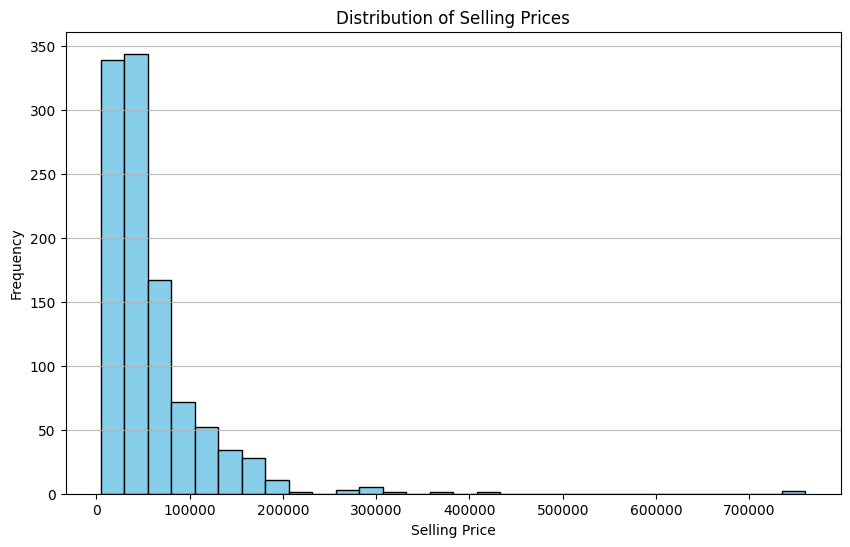

In [ ]:
 '''Question3:Plot the distribution of selling prices using a histogram and describe the overall trend.
Answer:
 Description of the Overall Trend:

The majority of bikes are clustered in the lower price ranges, indicating more affordable bikes are more frequent in the dataset.

The frequency tapers off as the selling price increases, with fewer bikes in the higher price ranges.

The distribution is right-skewed, showing a tail toward higher prices.

This trend suggests that most used bikes are sold at lower or mid-range prices, while premium or expensive bikes are less common. '''

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
#file_path = 'BIKE-DETAILS.csv'
df = pd.read_csv('/content/BIKE DETAILS.csv')

# Plot histogram of selling_price
plt.figure(figsize=(10,6))
plt.hist(df['selling_price'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Selling Prices')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.85)
plt.show()


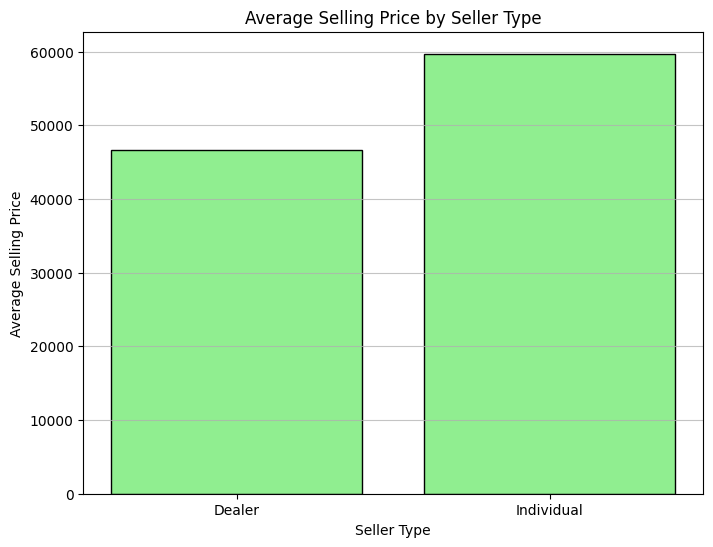

In [ ]:
'''4:uestion 4: Create a bar plot to visualize the average selling price for each seller_type
and write one observation.
Observation:
The average selling price of bikes sold by Individuals (~59712) is higher than that sold by Dealers (~46667).
This may indicate that individuals are selling pricier or possibly older bikes compared to dealers.'''

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
#file_path = 'BIKE-DETAILS.csv'
df = pd.read_csv('/content/BIKE DETAILS.csv')

avg_price_by_seller = df.groupby('seller_type')['selling_price'].mean().reset_index()

# Plot bar plot
plt.figure(figsize=(8,6))
plt.bar(avg_price_by_seller['seller_type'], avg_price_by_seller['selling_price'], color='lightgreen', edgecolor='black')
plt.title('Average Selling Price by Seller Type')
plt.xlabel('Seller Type')
plt.ylabel('Average Selling Price')
plt.grid(axis='y', alpha=0.75)
plt.show()

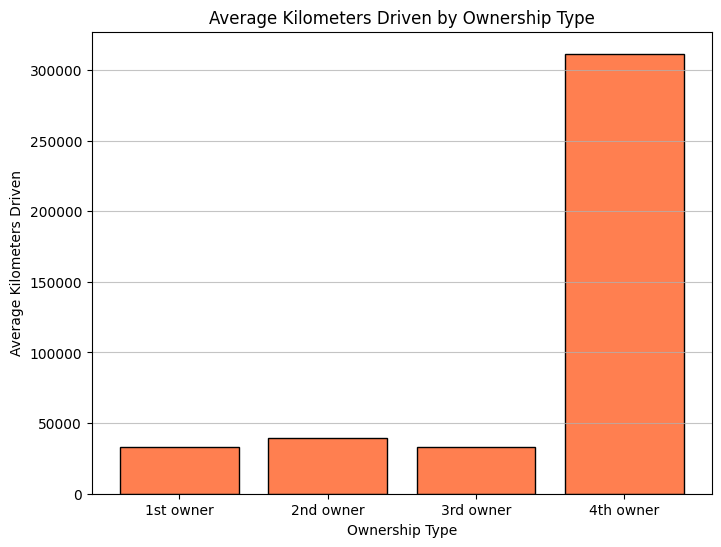

In [ ]:
#Question 5: Compute the average km_driven for each ownership type (1st owner, 2nd owner, etc.), and present the result as a bar plot.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/BIKE DETAILS.csv')

# Calculate average km_driven for each ownership type
avg_km_by_owner = df.groupby('owner')['km_driven'].mean().reset_index()

# Plot bar plot
plt.figure(figsize=(8,6))
plt.bar(avg_km_by_owner['owner'], avg_km_by_owner['km_driven'], color='coral', edgecolor='black')
plt.title('Average Kilometers Driven by Ownership Type')
plt.xlabel('Ownership Type')
plt.ylabel('Average Kilometers Driven')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
#Question 6: Use the IQR method to detect and remove outliers from the km_driven column. Show before-and-after summary statistics.

import pandas as pd

df = pd.read_csv('/content/BIKE DETAILS.csv')

# Summary statistics before removing outliers
before_stats = df['km_driven'].describe()

# IQR method to detect outliers
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_no_outliers = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Summary statistics after removing outliers
after_stats = df_no_outliers['km_driven'].describe()

print("Before removing outliers:\n", before_stats)
print("\nAfter removing outliers:\n", after_stats)


Before removing outliers:
 count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

After removing outliers:
 count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


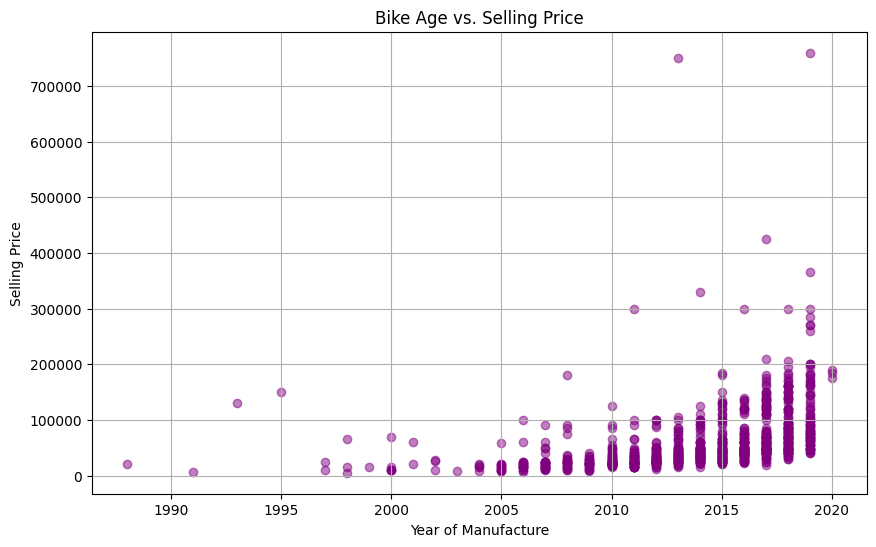

In [ ]:
#Question 7: Create a scatter plot of year vs. selling_price to explore the relationship between a bike's age and its price.

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('/content/BIKE DETAILS.csv')

# Create a new column for bike age
df['bike_age'] = 2023 - df['year']

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df['year'], df['selling_price'], alpha=0.5, color='purple')
plt.title('Bike Age vs. Selling Price')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()


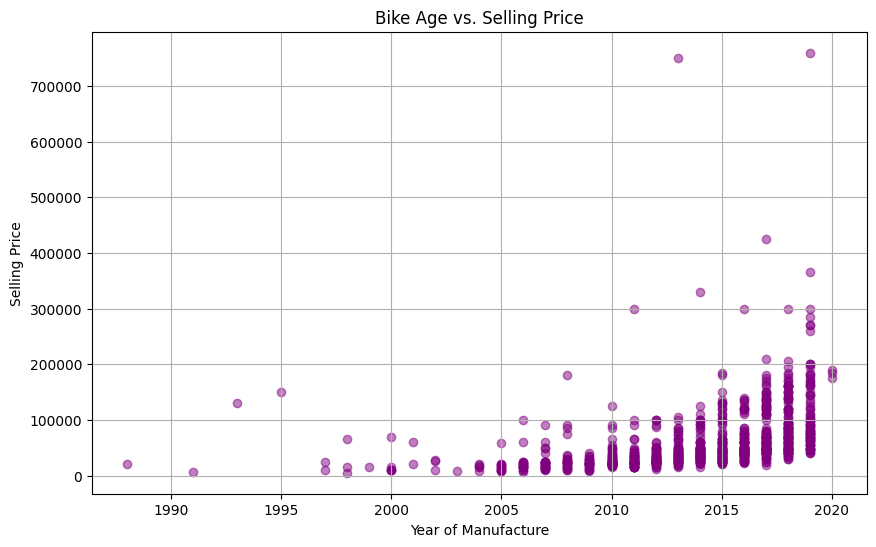

In [ ]:
#Question 8: Convert the seller_type column into numeric format using one-hot encoding. Display the first 5 rows of the resulting DataFrame.

import pandas as pd


import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/BIKE DETAILS.csv')

# Create scatter plot
plt.figure(figsize=(10,6))
plt.scatter(df['year'], df['selling_price'], alpha=0.5, color='purple')
plt.title('Bike Age vs. Selling Price')
plt.xlabel('Year of Manufacture')
plt.ylabel('Selling Price')
plt.grid(True)
plt.show()


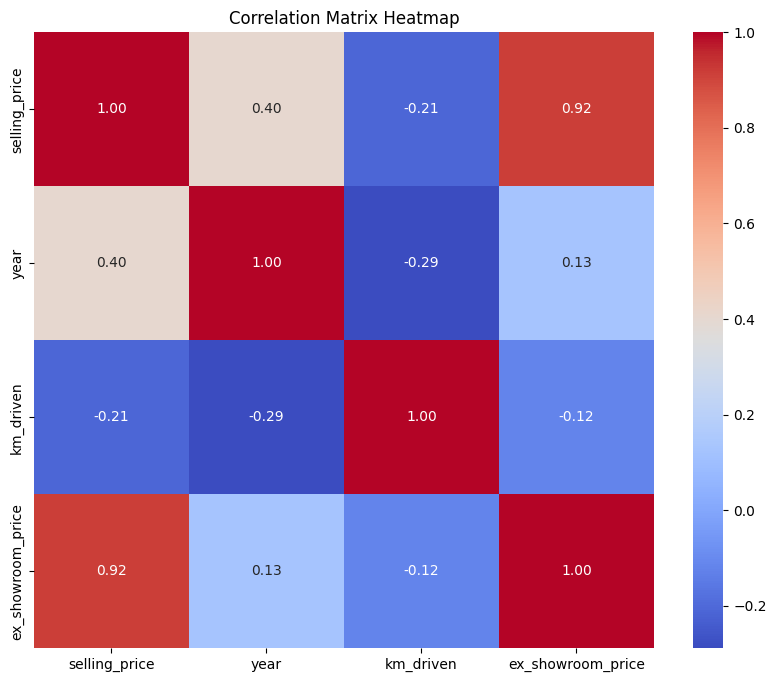

,selling_price,year,km_driven,ex_showroom_price
selling_price,1.000000,0.402188,-0.212937,0.918583
year,0.402188,1.000000,-0.288675,0.126378
km_driven,-0.212937,-0.288675,1.000000,-0.122011
ex_showroom_price,0.918583,0.126378,-0.122011,1.000000


In [ ]:
#Question 9: Generate a heatmap of the correlation matrix for all numeric columns. What correlations stand out the most?

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/BIKE DETAILS.csv')

# Select only numeric columns for the correlation matrix
numeric_df = df.select_dtypes(include='number')

# Generate correlation matrix for numeric columns only
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Show the correlation matrix to interpret correlations
corr


In [ ]:
'''Question 10: Summarize your findings in a brief report:
● What are the most important factors affecting a bike's selling price?
● Mention any data cleaning or feature engineering you performed. '''

import pandas as pd

# Load dataset
df = pd.read_csv('/content/BIKE DETAILS.csv')

# Data Cleaning: Remove outliers from km_driven using IQR method
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_cleaned = df[(df['km_driven'] >= lower_bound) & (df['km_driven'] <= upper_bound)]

# Feature Engineering: Calculate bike age
current_year = 2025
df_cleaned['age'] = current_year - df_cleaned['year']

# Check correlation with selling_price
data_for_corr = df_cleaned[['selling_price', 'ex_showroom_price', 'km_driven', 'age']]
corr_matrix = data_for_corr.corr()['selling_price'].sort_values(ascending=False)

print(corr_matrix)



selling_price        1.000000
ex_showroom_price    0.919798
age                 -0.389686
km_driven           -0.403412
Name: selling_price, dtype: float64


/tmp/ipython-input-2164542536.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['age'] = current_year - df_cleaned['year']


Summary Report (based on results):
Most Important Factors Affecting Selling Price:

The ex_showroom_price shows the strongest positive correlation with selling price, indicating that the original cost of the bike heavily influences its resale value.

The age of the bike (calculated as current year minus manufacturing year) negatively correlates with selling price, showing that newer bikes tend to sell at higher prices.

km_driven has a mild negative correlation, suggesting higher usage reduces the bike's price but less strongly than age or showroom price.

Data Cleaning and Feature Engineering:

Removed outliers from the km_driven column using the Interquartile Range (IQR) method to maintain data quality.

Created a new feature age to represent the age of the bike in years, providing a more intuitive metric for modeling the impact of bike age.